In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df[df['job_posted_date'].dt.year == 2025 ]

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\frase\AppData\Local\Temp\ipykernel_12020\658645251.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_filtered, x = 'salary_year_avg',y = 'job_title_short', order = job_list, medianprops={'color': 'black','linewidth': 1.2}, boxprops = {'alpha':0.6}, palette = 'Set1')


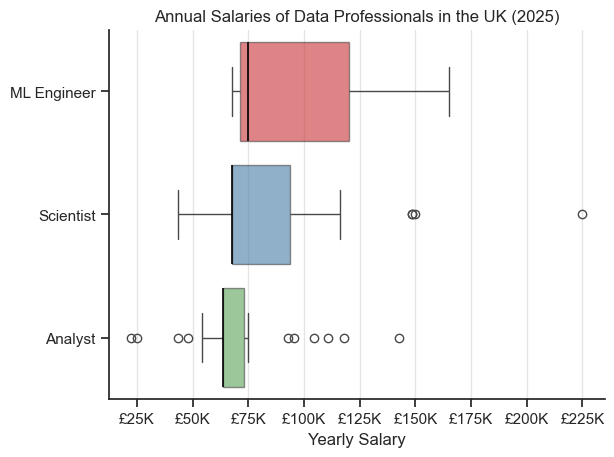

In [38]:
job_titles = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']
df_filtered = df[(df['job_country'] == 'United Kingdom')
                 & df['job_title_short'].isin(job_titles)]
df_filtered = df_filtered.dropna(subset = ['salary_year_avg']).reset_index()
df_filtered['salary_year_avg'] = df_filtered['salary_year_avg'] * 0.75
label_map = {
    'Data Analyst': 'Analyst',
    'Data Scientist': 'Scientist',
    'Machine Learning Engineer': 'ML Engineer'
}

df_filtered['job_title_short'] = (
    df_filtered['job_title_short'].replace(label_map)
)
df_salaries = (
    df_filtered.groupby('job_title_short')['salary_year_avg'].median()
    .sort_values(ascending = False)
)
job_list = df_salaries.index


sns.set_theme(style = 'ticks')
sns.boxplot(data = df_filtered, x = 'salary_year_avg',y = 'job_title_short', order = job_list, medianprops={'color': 'black','linewidth': 1.2}, boxprops = {'alpha':0.6}, palette = 'Set1')
sns.despine()
plt.title('Annual Salaries of Data Professionals in the UK (2025)')
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.grid(axis='x', alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'£{int(x/1000)}K'))
plt.show()

In [43]:
df_filtered[df_filtered['job_title_short'] == 'ML Engineer']

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
10,1332875,ML Engineer,Machine Learning Engineer,"Washington, United Kingdom",Vaia,Full-time,False,United Kingdom,2025-01-31 00:33:42,False,False,United Kingdom,year,67500.0,NaN,"Amida Technology Solutions, Inc.","[python, bash, powershell, azure, databricks, ...","{'cloud': ['azure', 'databricks'], 'libraries'..."
51,1615833,ML Engineer,MLOps Engineer - Scalable Data Pipelines,"Boston, United Kingdom",BeBee GB,Full-time,False,United Kingdom,2025-07-12 10:32:48,False,False,United Kingdom,year,165000.0,NaN,beBeeMl,"[python, snowflake, bigquery, pytorch, tensorf...","{'cloud': ['snowflake', 'bigquery'], 'librarie..."
63,1702440,ML Engineer,Mathematical Modeler,"Dundee, United Kingdom",BeBee GB,Full-time,False,United Kingdom,2025-10-07 12:06:57,False,False,United Kingdom,year,75000.0,NaN,DataAnnotation,NaN,NaN
